In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav


In [3]:
# Cell 2 — Imports
# Same stack as before. No new libraries needed —
# the entire upgrade lives in how we extract features.

!pip install librosa -q

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Input, Multiply, Lambda, Softmax, Bidirectional, Masking
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-04-29 06:58:41.277702: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777445921.465800      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777445921.516037      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777445921.954161      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777445921.954206      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777445921.954209      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:


emotion_map = {
    '01': 'neutral',  '02': 'calm',     '03': 'happy',    '04': 'sad',
    '05': 'angry',    '06': 'fearful',  '07': 'disgust',  '08': 'surprised'
}

file_paths, emotions = [], []

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.wav'):
            parts = filename.split('-')
            label = emotion_map.get(parts[2])
            if label:
                file_paths.append(os.path.join(dirname, filename))
                emotions.append(label)

df = pd.DataFrame({'path': file_paths, 'emotion': emotions})
print(f"Total files: {len(df)}")
print(df['emotion'].value_counts())

Total files: 2880
emotion
surprised    384
disgust      384
fearful      384
sad          384
happy        384
calm         384
angry        384
neutral      192
Name: count, dtype: int64


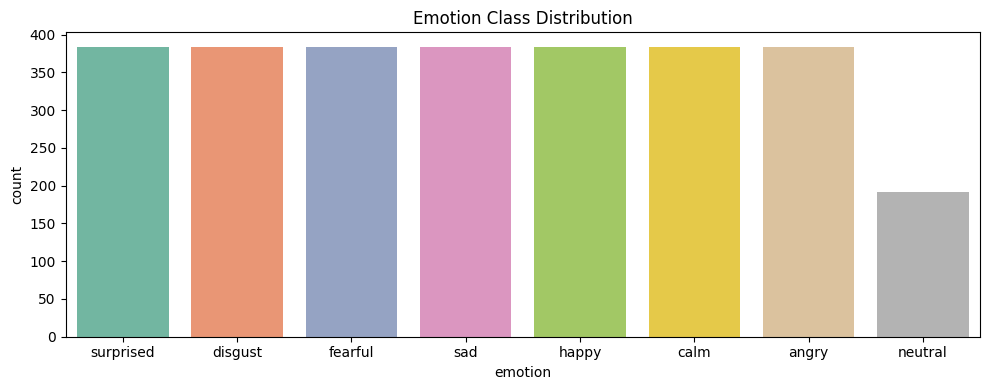

Unique emotions: 8
emotion
surprised    384
disgust      384
fearful      384
sad          384
happy        384
calm         384
angry        384
neutral      192
Name: count, dtype: int64


In [5]:

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='emotion',
              order=df['emotion'].value_counts().index, palette='Set2')
plt.title('Emotion Class Distribution')
plt.tight_layout()
plt.show()

print("Unique emotions:", df['emotion'].nunique())
print(df['emotion'].value_counts())

In [6]:


SR         = 22050
DURATION   = 3
HOP_LENGTH = 512
N_MFCC     = 40
MAX_FRAMES = 1 + int(np.floor(DURATION * SR / HOP_LENGTH))  # = 130
N_FEATURES = N_MFCC * 3   # MFCCs + delta + delta-delta = 120

print(f"Audio config:")
print(f"  Sample rate  : {SR} Hz")
print(f"  Duration     : {DURATION}s")
print(f"  Hop length   : {HOP_LENGTH} samples ({HOP_LENGTH/SR*1000:.1f}ms per frame)")
print(f"  Max frames   : {MAX_FRAMES}")
print(f"  Features/frame: {N_FEATURES}  (MFCCs + Δ + ΔΔ)")
print(f"  Tensor shape : ({MAX_FRAMES}, {N_FEATURES}) per file")


def extract_frame_features(file_path):
    """
    Returns a (MAX_FRAMES, N_FEATURES) array for one audio file.
    Rows = time frames, Columns = [mfccs | delta | delta-delta]
    """
    try:
        # Load and clip/pad to exactly DURATION seconds
        audio, sr = librosa.load(file_path, sr=SR, duration=DURATION)
        expected  = DURATION * SR
        if len(audio) < expected:
            audio = np.pad(audio, (0, expected - len(audio)))

        mfccs  = librosa.feature.mfcc(y=audio, sr=sr,
                                       n_mfcc=N_MFCC,
                                       hop_length=HOP_LENGTH)


        delta  = librosa.feature.delta(mfccs, width=9)

        delta2 = librosa.feature.delta(mfccs, order=2, width=9)

        combined = np.vstack([mfccs, delta, delta2]).T  # (T, 120)

        # ── Pad or truncate to MAX_FRAMES ──────────────────────────
        T = combined.shape[0]
        if T < MAX_FRAMES:
            # Post-pad with zeros (silence)
            pad_width = MAX_FRAMES - T
            combined  = np.pad(combined, ((0, pad_width), (0, 0)))
        else:
            combined = combined[:MAX_FRAMES]   # truncate if longer

        return combined.astype(np.float32)     # (130, 120)

    except Exception as e:
        print(f"Error: {file_path} → {e}")
        return None


# ── Extract for all files ──────────────────────────────────────
print("\nExtracting frame-level features...")
print("(~4-6 minutes — more work per file than notebook 1)\n")

X_list, valid_idx = [], []
for i, path in enumerate(df['path']):
    feat = extract_frame_features(path)
    if feat is not None:
        X_list.append(feat)
        valid_idx.append(i)
    if i % 300 == 0:
        print(f"  {i}/{len(df)} files processed...")

X = np.array(X_list)   # (N, 130, 120)
y = df['emotion'].iloc[valid_idx].values

print(f"\nFeature tensor shape : {X.shape}")
print(f"  axis 0 = files     : {X.shape[0]}")
print(f"  axis 1 = frames    : {X.shape[1]}  ← the real time sequence")
print(f"  axis 2 = features  : {X.shape[2]}  per frame")
print(f"Notebook has shape : {X.shape}  — a sequence per file")

Audio config:
  Sample rate  : 22050 Hz
  Duration     : 3s
  Hop length   : 512 samples (23.2ms per frame)
  Max frames   : 130
  Features/frame: 120  (MFCCs + Δ + ΔΔ)
  Tensor shape : (130, 120) per file

Extracting frame-level features...
(~4-6 minutes — more work per file than notebook 1)

  0/2880 files processed...
  300/2880 files processed...
  600/2880 files processed...
  900/2880 files processed...
  1200/2880 files processed...
  1500/2880 files processed...
  1800/2880 files processed...
  2100/2880 files processed...
  2400/2880 files processed...
  2700/2880 files processed...

Feature tensor shape : (2880, 130, 120)
  axis 0 = files     : 2880
  axis 1 = frames    : 130  ← the real time sequence
  axis 2 = features  : 120  per frame

Notebook 1 had shape : (2880, 180)  — one vector per file
Notebook 2 has shape : (2880, 130, 120)  — a sequence per file


In [12]:


le          = LabelEncoder()
y_encoded   = le.fit_transform(y)
y_onehot    = to_categorical(y_encoded)
num_classes = y_onehot.shape[1]

print(f"Classes: {list(le.classes_)}")
print(f"Num classes: {num_classes}")

# ── Train / Val / Test split: 70 / 15 / 15 ────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=0.3, random_state=42,
    stratify=y_onehot.argmax(1)
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
    stratify=y_temp.argmax(1)
)

print(f"\nSplit sizes:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")

# ── Scale: reshape 3D→2D, fit, reshape back ───────────────────
N_train, T, F = X_train.shape

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N_train, T, F)
X_val_s   = scaler.transform(X_val.reshape(-1, F)).reshape(X_val.shape)
X_test_s  = scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape)

print(f"\nAfter scaling:")
print(f"  Train mean ≈ {X_train_s.mean():.4f}  (should be ~0)")
print(f"  Train std  ≈ {X_train_s.std():.4f}   (should be ~1)")

#Class weights to fix neutral imbalance

neutral_idx = list(le.classes_).index('neutral')
class_weight = {i: 1.0 for i in range(num_classes)}
class_weight[neutral_idx] = 2.0   # neutral gets 2x loss penalty

print(f"\nClass weights:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls:<12} → weight {class_weight[i]}")

Classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Num classes: 8

Split sizes:
  Train : (2016, 130, 120)
  Val   : (432, 130, 120)
  Test  : (432, 130, 120)

After scaling:
  Train mean ≈ -0.0000  (should be ~0)
  Train std  ≈ 1.0000   (should be ~1)

Class weights:
  angry        → weight 1.0
  calm         → weight 1.0
  disgust      → weight 1.0
  fearful      → weight 1.0
  happy        → weight 1.0
  neutral      → weight 2.0
  sad          → weight 1.0
  surprised    → weight 1.0


In [25]:



import tensorflow as tf
import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Input, Multiply, Bidirectional, Layer
)


# ── Custom Layer 1: Softmax over time axis ────────────────────────────
@keras.utils.register_keras_serializable(package='EmotionModel')
class SoftmaxOverTime(Layer):
    """
    Applies softmax over axis=1 (the time/timestep axis).

    Why a custom layer instead of Lambda?
    → Keras can serialize 'EmotionModel>SoftmaxOverTime' as a string.
    → On load, it looks up this registered class by name.
    → No bytecode, no security issue, works with safe_mode=True.

    Input:  (batch, T, 1) — raw attention scores
    Output: (batch, T, 1) — normalized attention weights (sum to 1 over T)
    """
    def call(self, inputs):
        return tf.nn.softmax(inputs, axis=1)

    def get_config(self):
        # get_config() is what Keras calls when saving.
        # We have no hyperparameters to store, so just call super().
        return super().get_config()


# ── Custom Layer 2: Sum over time axis ───────────────────────────────
@keras.utils.register_keras_serializable(package='EmotionModel')
class WeightedSum(Layer):
    """
    Sums over axis=1 (the time axis) to produce a context vector.

    Input:  (batch, T, units) — weighted hidden states
    Output: (batch, units)    — context vector (sum across T)

    This collapses the sequence into a single vector that carries
    information from all timesteps, weighted by attention scores.
    """
    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=1)

    def get_config(self):
        return super().get_config()


# ── Attention function ────────────────────────────────────────────────
def attention_layer(lstm_output):
    """
    Bahdanau-style attention using only serializable Keras layers.

    lstm_output : (batch, T, units)

    Returns:
        context          : (batch, units)  — weighted sum across T
        attention_weights: (batch, T, 1)   — one weight per frame
    """
    # Score: one scalar per timestep
    score = Dense(1, activation='tanh', name='attention_score')(lstm_output)
    # (batch, T, 1)

    # Normalize scores across time → attention weights
    attention_weights = SoftmaxOverTime(name='attention_weights')(score)
    # (batch, T, 1)

    # Weighted hidden states
    weighted = Multiply(name='attention_multiply')([lstm_output, attention_weights])
    # (batch, T, units)

    # Collapse time axis → context vector
    context = WeightedSum(name='attention_context')(weighted)
    # (batch, units)

    return context, attention_weights


# ── Model builder ─────────────────────────────────────────────────────
def build_bilstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape, name='input')   # (batch, 130, 120)

    # ── First BiLSTM ─────────────────────────────────────────────
    x = Bidirectional(
        LSTM(128, return_sequences=True),
        name='bilstm_1'
    )(inputs)                                          # (batch, 130, 256)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(0.3, name='drop_1')(x)

    # ── Second BiLSTM ────────────────────────────────────────────
    x = Bidirectional(
        LSTM(64, return_sequences=True),
        name='bilstm_2'
    )(x)                                               # (batch, 130, 128)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(0.3, name='drop_2')(x)

    # ── Attention ─────────────────────────────────────────────────
    context, attention_weights = attention_layer(x)
    # context:           (batch, 128)
    # attention_weights: (batch, 130, 1)

    # ── Classification head ───────────────────────────────────────
    x = BatchNormalization(name='bn_3')(context)
    x = Dropout(0.4, name='drop_3')(x)
    x = Dense(128, activation='relu', name='dense_1')(x)
    x = Dropout(0.3, name='drop_4')(x)
    x = Dense(64,  activation='relu', name='dense_2')(x)
    x = Dropout(0.3, name='drop_5')(x)
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    full_model = Model(
        inputs=inputs, outputs=outputs,
        name='BiLSTM_Emotion'
    )
    attention_model = Model(
        inputs=inputs, outputs=attention_weights,
        name='BiLSTM_Attention'
    )

    full_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return full_model, attention_model


input_shape = (MAX_FRAMES, N_FEATURES)
model, attention_model = build_bilstm_model(input_shape, num_classes)
model.summary()

print(f"\nInput : {input_shape}  ({MAX_FRAMES} frames × {N_FEATURES} features)")


Model: "BiLSTM_Emotion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 130, 120)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 130, 256)  │    254,976 │ input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 130, 256)  │      1,024 │ bilstm_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 130, 256)  │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 130, 128)  │    164,352 │ drop_1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 130, 128)  │        512 │ bilstm_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 130, 128)  │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 130, 1)    │        129 │ drop_2[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 130, 1)    │          0 │ attention_score[… │
│ (SoftmaxOverTime)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_multiply  │ (None, 130, 128)  │          0 │ drop_2[0][0],     │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_context   │ (None, 128)       │          0 │ attention_multip… │
│ (WeightedSum)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 128)       │        512 │ attention_contex… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 128)       │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ drop_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_4 (Dropout)    │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ drop_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_5 (Dropout)    │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8)         │        520 │ drop_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 446,793 (1.70 MB)

 Trainable params: 445,769 (1.70 MB)

 Non-trainable params: 1,024 (4.00 KB)


Input : (130, 120)  (130 frames × 120 features)


In [26]:

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_bilstm_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,   # ← new: fix neutral imbalance
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest Val Accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best Val Loss     : {min(history.history['val_loss']):.4f}")

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1661 - loss: 2.5660
Epoch 1: val_accuracy improved from -inf to 0.26157, saving model to best_bilstm_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.1667 - loss: 2.5624 - val_accuracy: 0.2616 - val_loss: 1.9721 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2937 - loss: 1.9873
Epoch 2: val_accuracy improved from 0.26157 to 0.41204, saving model to best_bilstm_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.2937 - loss: 1.9866 - val_accuracy: 0.4120 - val_loss: 1.8214 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3993 - loss: 1.6901
Epoch 3: val_accuracy improved from 0.41204 to 0.49306, saving model to best_bilstm_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.3997 - loss: 1.6892 - val_accuracy: 0.4931 - val_loss: 1.4705 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━

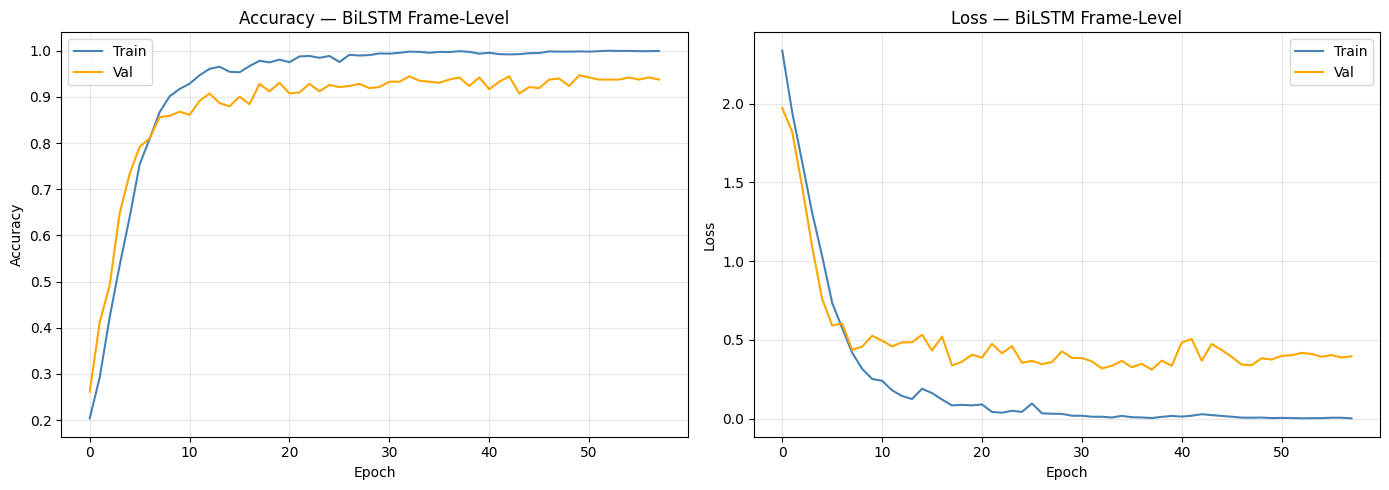

Best Val Accuracy : 0.9468
Best Val Loss     : 0.3117
Epochs trained    : 58


In [27]:
#

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('Accuracy — BiLSTM Frame-Level')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
axes[1].set_title('Loss — BiLSTM Frame-Level')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Val Accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best Val Loss     : {min(history.history['val_loss']):.4f}")
print(f"Epochs trained    : {len(history.history['loss'])}")

In [28]:
# Cell 10 — Evaluate on Test Set

test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}")
print(f"\nNotebook 1 was: 86.57% — delta = {(test_acc - 0.8657)*100:+.2f}%")

y_pred  = np.argmax(model.predict(X_test_s, verbose=0), axis=1)
y_true  = np.argmax(y_test, axis=1)
y_pred_labels = le.inverse_transform(y_pred)
y_true_labels = le.inverse_transform(y_true)

print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, digits=4))

Test Accuracy : 0.9329  (93.29%)
Test Loss     : 0.3813

Notebook 1 was: 86.57% — delta = +6.72%

Classification Report:
              precision    recall  f1-score   support

       angry     0.9630    0.9123    0.9369        57
        calm     0.9661    1.0000    0.9828        57
     disgust     0.9636    0.9138    0.9381        58
     fearful     0.8889    0.9655    0.9256        58
       happy     0.8814    0.8966    0.8889        58
     neutral     0.8750    0.9655    0.9180        29
         sad     0.9811    0.9123    0.9455        57
   surprised     0.9298    0.9138    0.9217        58

    accuracy                         0.9329       432
   macro avg     0.9311    0.9350    0.9322       432
weighted avg     0.9346    0.9329    0.9330       432



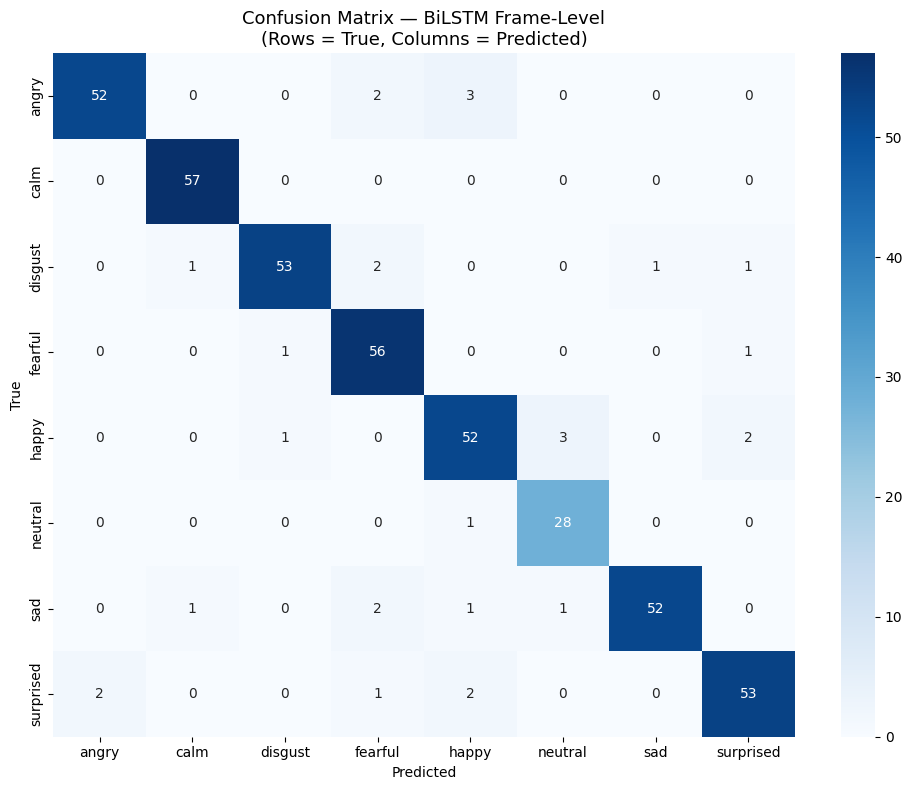


Per-class recall (how often each emotion is correctly identified):
  angry        52/57  = 91.2%
  calm         57/57  = 100.0%
  disgust      53/58  = 91.4%
  fearful      56/58  = 96.6%
  happy        52/58  = 89.7%
  neutral      28/29  = 96.6%
  sad          52/57  = 91.2%
  surprised    53/58  = 91.4%


In [29]:

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=le.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — BiLSTM Frame-Level\n'
          '(Rows = True, Columns = Predicted)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class recall (how often each emotion is correctly identified):")
for i, cls in enumerate(le.classes_):
    row_sum = cm[i].sum()
    correct = cm[i, i]
    print(f"  {cls:<12} {correct}/{row_sum}  = {correct/row_sum:.1%}")

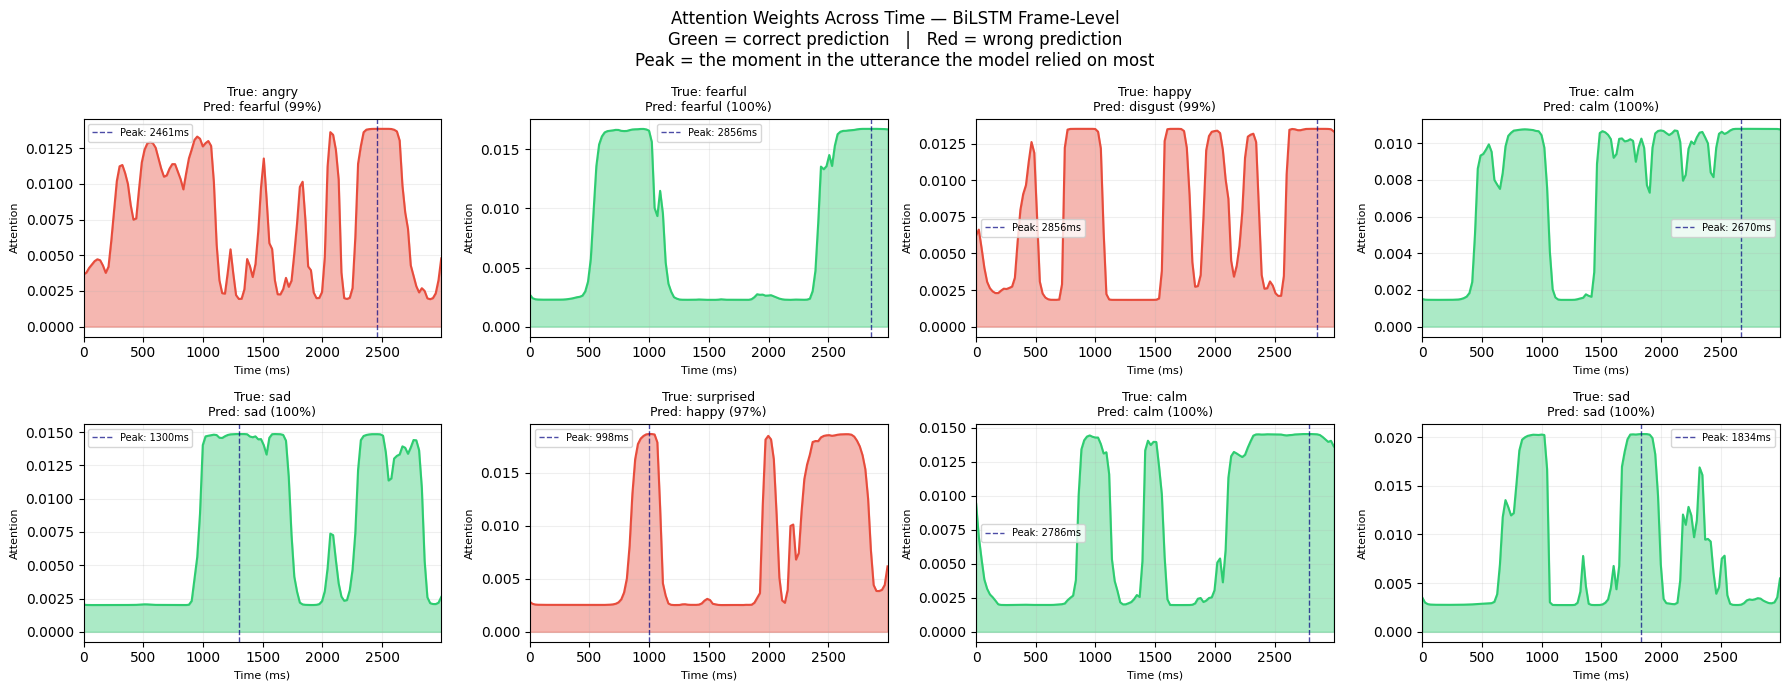


Computing per-emotion average attention curves...


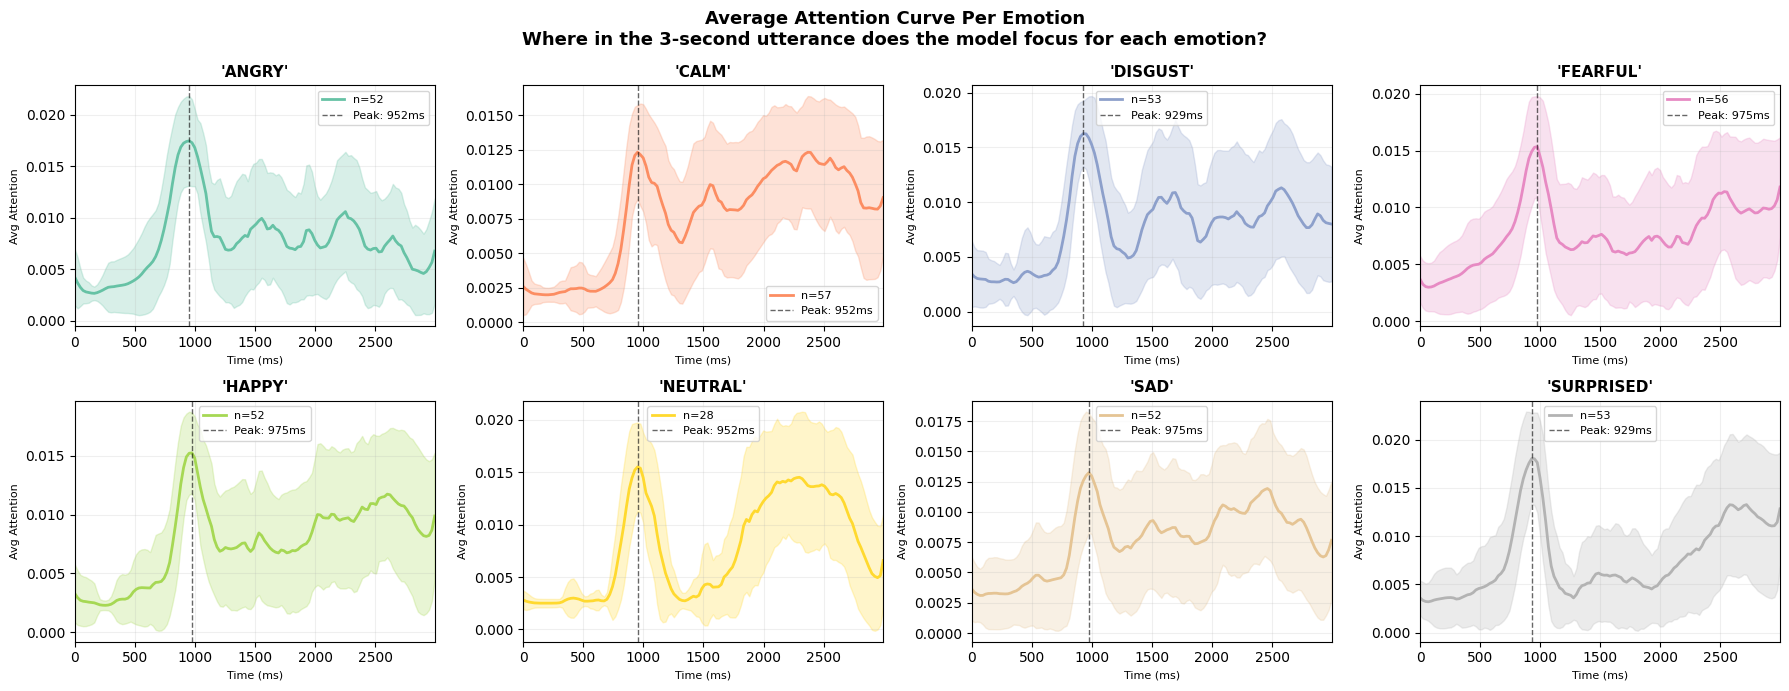

In [31]:


n_show = 8
sample_indices = np.random.choice(len(X_test_s), n_show, replace=False)
time_axis = np.arange(MAX_FRAMES) * (HOP_LENGTH / SR) * 1000  # ms

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for idx, sample_i in enumerate(sample_indices):
    sample     = X_test_s[sample_i:sample_i+1]           # (1, 130, 120)
    attn       = attention_model.predict(sample, verbose=0)[0, :, 0]  # (130,)
    pred_probs = model.predict(sample, verbose=0)[0]
    true_label = le.inverse_transform([np.argmax(y_test[sample_i])])[0]
    pred_label = le.inverse_transform([np.argmax(pred_probs)])[0]
    confidence = np.max(pred_probs)

    correct = true_label == pred_label
    color   = '#2ecc71' if correct else '#e74c3c'

    axes[idx].fill_between(time_axis, attn, alpha=0.4, color=color)
    axes[idx].plot(time_axis, attn, color=color, linewidth=1.5)
    axes[idx].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.0%})",
        fontsize=9,
        color='black'
    )
    axes[idx].set_xlabel('Time (ms)', fontsize=8)
    axes[idx].set_ylabel('Attention', fontsize=8)
    axes[idx].set_xlim(0, time_axis[-1])
    axes[idx].grid(True, alpha=0.2)

    # Mark the peak attention frame
    peak_ms = time_axis[np.argmax(attn)]
    axes[idx].axvline(peak_ms, color='navy', linestyle='--',
                      linewidth=1, alpha=0.7, label=f'Peak: {peak_ms:.0f}ms')
    axes[idx].legend(fontsize=7)

plt.suptitle(
    'Attention Weights Across Time — BiLSTM Frame-Level\n'
    'Green = correct prediction   |   Red = wrong prediction\n'
    'Peak = the moment in the utterance the model relied on most',
    fontsize=12
)
plt.tight_layout()
plt.show()



print("\nComputing per-emotion average attention curves...")

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
cmap_colors = plt.cm.Set2(np.linspace(0, 1, num_classes))

for c_idx, emotion in enumerate(le.classes_):
    ax = axes[c_idx]

    # Collect correctly predicted samples of this emotion
    correct_samples = [
        i for i in range(len(X_test_s))
        if le.inverse_transform([np.argmax(y_test[i])])[0] == emotion
        and le.inverse_transform([np.argmax(
            model.predict(X_test_s[i:i+1], verbose=0))])[0] == emotion
    ]

    if not correct_samples:
        ax.set_title(f"'{emotion}'\n(no correct samples)")
        continue

    # Compute attention for each correct sample
    attn_curves = []
    for i in correct_samples:
        attn = attention_model.predict(X_test_s[i:i+1], verbose=0)[0, :, 0]
        attn_curves.append(attn)

    attn_curves = np.array(attn_curves)  # (n_correct, 130)
    mean_attn   = attn_curves.mean(axis=0)
    std_attn    = attn_curves.std(axis=0)

    color = cmap_colors[c_idx]
    ax.fill_between(time_axis, mean_attn - std_attn,
                    mean_attn + std_attn, alpha=0.25, color=color)
    ax.plot(time_axis, mean_attn, color=color, linewidth=2,
            label=f'n={len(correct_samples)}')

    peak_ms = time_axis[np.argmax(mean_attn)]
    ax.axvline(peak_ms, color='black', linestyle='--',
               linewidth=1, alpha=0.6, label=f'Peak: {peak_ms:.0f}ms')

    ax.set_title(f"'{emotion.upper()}'", fontweight='bold', fontsize=11)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Avg Attention', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, time_axis[-1])

plt.suptitle(
    'Average Attention Curve Per Emotion\n'
    'Where in the 3-second utterance does the model focus for each emotion?',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [32]:


!pip install shap lime -q
import shap
import lime
import lime.lime_tabular

n_samples = X_test_s.shape[0]
X_test_flat  = X_test_s.reshape(n_samples, -1)          # (432, 15600)
X_train_flat = X_train_s.reshape(X_train_s.shape[0], -1)

def model_predict_flat(X_flat):
    """Wrapper: SHAP passes 2D, model needs 3D."""
    X_3d = X_flat.reshape(-1, MAX_FRAMES, N_FEATURES)
    return model.predict(X_3d, verbose=0)

#  80 (15600 features is heavy)
bg_idx  = np.random.choice(X_train_flat.shape[0], 80, replace=False)
background = X_train_flat[bg_idx]

print("Initializing SHAP KernelExplainer...")
print("(With 15600 features this will take longer than notebook 1 — ~10-15 min)")
explainer = shap.KernelExplainer(model_predict_flat, background)

explain_idx  = np.random.choice(X_test_flat.shape[0], 30, replace=False)
X_explain_flat = X_test_flat[explain_idx]

print(f"Computing SHAP values for 30 samples × 15600 features...")
shap_values = explainer.shap_values(X_explain_flat, nsamples=100)
shap_array  = np.array(shap_values)
print(f"shap_array.shape: {shap_array.shape}")
if shap_array.shape[0] == num_classes:
    # (n_classes, n_samples, n_flat_features)
    shap_3d = shap_array.transpose(1, 2, 0).reshape(30, MAX_FRAMES, N_FEATURES, num_classes)
elif shap_array.shape[-1] == num_classes:
    # (n_samples, n_flat_features, n_classes)
    shap_3d = shap_array.reshape(30, MAX_FRAMES, N_FEATURES, num_classes)
else:
    print(f"Unexpected shape {shap_array.shape} — check manually")
    shap_3d = None

print(f"shap_3d.shape: {shap_3d.shape}")
# (30, 130, 120, 8) = (samples, frames, features, classes)

Initializing SHAP KernelExplainer...
(With 15600 features this will take longer than notebook 1 — ~10-15 min)
Computing SHAP values for 30 samples × 15600 features...


  0%|          | 0/30 [00:00<?, ?it/s]

shap_array.shape: (30, 15600, 8)
shap_3d.shape: (30, 130, 120, 8)


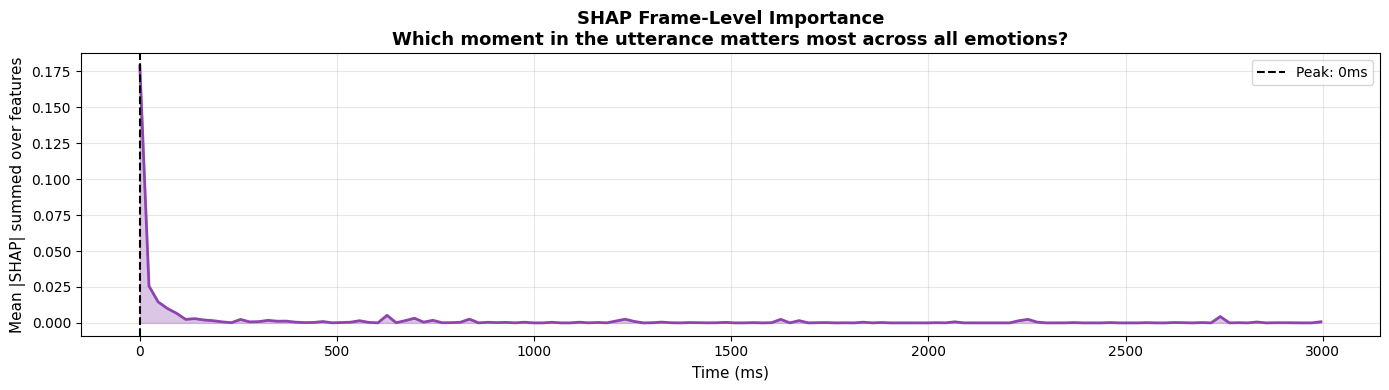

SHAP peak frame: 0ms  (frame 0/130)


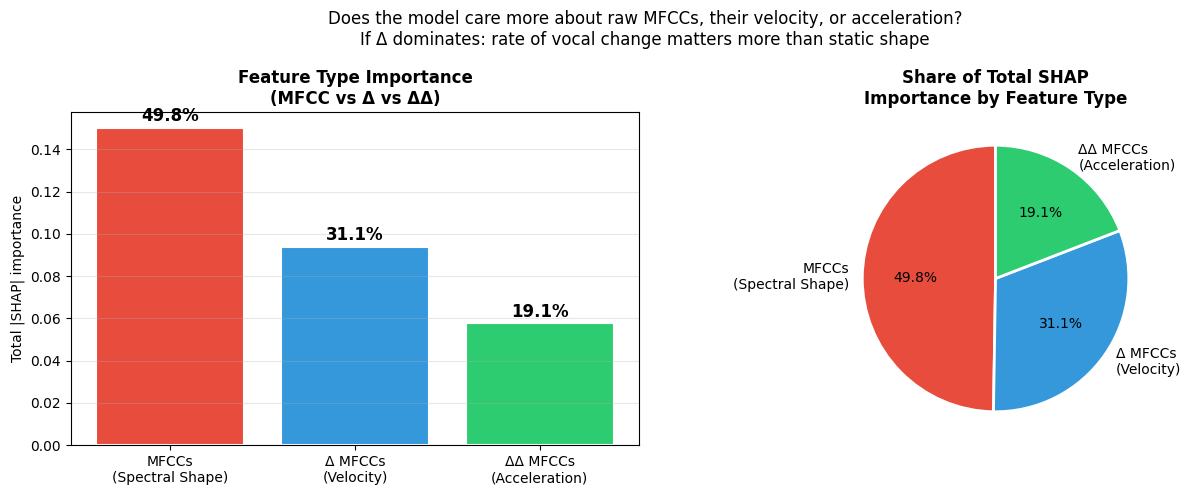

MFCCs (raw)    : 0.1502   (49.8%)
Delta          : 0.0939   (31.1%)
Delta-delta    : 0.0578   (19.1%)

Computing mean attention curve across all test samples...


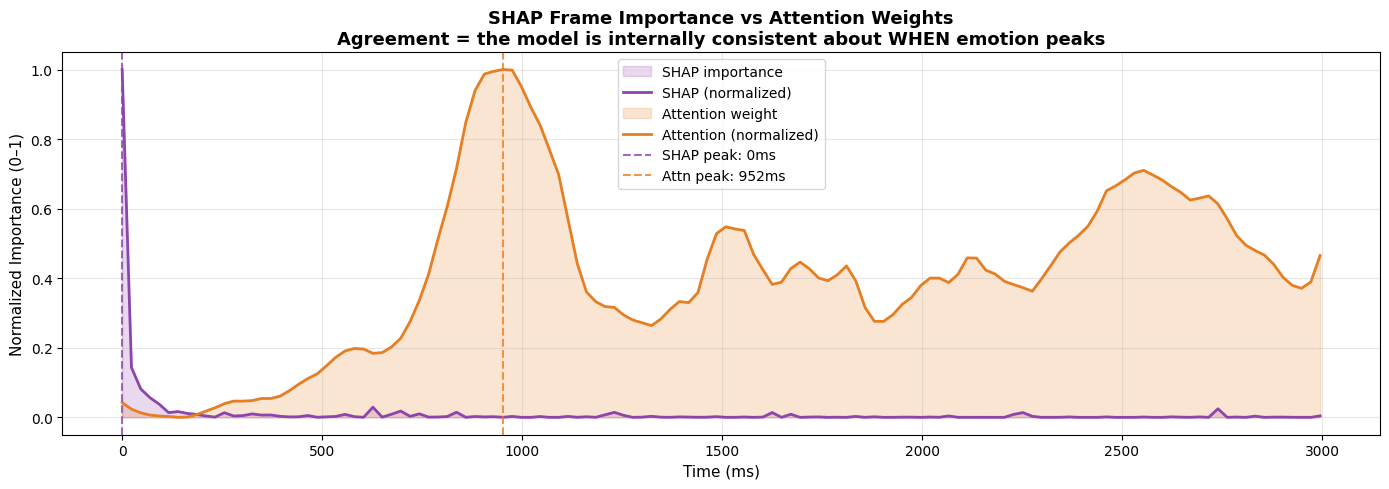


SHAP–Attention correlation: r = -0.188  (p = 0.0325)
  r > 0.6  → strong agreement (model is consistent)
  r < 0.3  → weak agreement  (attention and SHAP disagree on timing)


In [34]:

import matplotlib.patches as mpatches

if shap_3d is not None:

    
    abs_shap = np.abs(shap_3d)  # (30, 130, 120, 8)

    shap_per_frame   = abs_shap.sum(axis=2).mean(axis=(0, 2))  # (130,)

    # Per-feature-type: sum over frames, mean over samples and classes
    shap_per_feature = abs_shap.sum(axis=1).mean(axis=(0, 2))  # (120,)
    shap_mfcc        = shap_per_feature[:40].sum()
    shap_delta       = shap_per_feature[40:80].sum()
    shap_delta2      = shap_per_feature[80:].sum()
    total_shap       = shap_mfcc + shap_delta + shap_delta2

    # ── PLOT 1: Per-Frame SHAP importance ─────────────────────
    plt.figure(figsize=(14, 4))
    plt.fill_between(time_axis, shap_per_frame, alpha=0.3, color='#8e44ad')
    plt.plot(time_axis, shap_per_frame, color='#8e44ad', linewidth=2)
    peak_frame_ms = time_axis[np.argmax(shap_per_frame)]
    plt.axvline(peak_frame_ms, color='black', linestyle='--',
                linewidth=1.5, label=f'Peak: {peak_frame_ms:.0f}ms')
    plt.xlabel('Time (ms)', fontsize=11)
    plt.ylabel('Mean |SHAP| summed over features', fontsize=11)
    plt.title(
        'SHAP Frame-Level Importance\n'
        'Which moment in the utterance matters most across all emotions?',
        fontsize=13, fontweight='bold'
    )
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"SHAP peak frame: {peak_frame_ms:.0f}ms  "
          f"(frame {np.argmax(shap_per_frame)}/{MAX_FRAMES})")

    # ── PLOT 2: MFCC vs Delta vs Delta-Delta importance ────────
    groups  = ['MFCCs\n(Spectral Shape)', 'Δ MFCCs\n(Velocity)',
               'ΔΔ MFCCs\n(Acceleration)']
    values  = [shap_mfcc, shap_delta, shap_delta2]
    pcts    = [v / total_shap * 100 for v in values]
    colors  = ['#e74c3c', '#3498db', '#2ecc71']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    bars = ax1.bar(groups, values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, pct, val in zip(bars, pcts, values):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + total_shap * 0.01,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Total |SHAP| importance')
    ax1.set_title('Feature Type Importance\n(MFCC vs Δ vs ΔΔ)', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    ax2.pie(values, labels=groups, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax2.set_title('Share of Total SHAP\nImportance by Feature Type', fontweight='bold')

    plt.suptitle(
        'Does the model care more about raw MFCCs, their velocity, or acceleration?\n'
        'If Δ dominates: rate of vocal change matters more than static shape',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    print(f"MFCCs (raw)    : {shap_mfcc:.4f}   ({pcts[0]:.1f}%)")
    print(f"Delta          : {shap_delta:.4f}   ({pcts[1]:.1f}%)")
    print(f"Delta-delta    : {shap_delta2:.4f}   ({pcts[2]:.1f}%)")

    # ── PLOT 3: SHAP vs Attention agreement ────────────────────
    # Compute mean attention curve across all test samples
    print("\nComputing mean attention curve across all test samples...")
    all_attn = []
    for i in range(0, len(X_test_s), 10):   # every 10th sample for speed
        attn = attention_model.predict(X_test_s[i:i+1], verbose=0)[0, :, 0]
        all_attn.append(attn)
    mean_attn_curve = np.mean(all_attn, axis=0)  # (130,)

    # Normalize both curves to [0,1] for overlay
    shap_norm = (shap_per_frame - shap_per_frame.min()) / (shap_per_frame.max() - shap_per_frame.min())
    attn_norm = (mean_attn_curve - mean_attn_curve.min()) / (mean_attn_curve.max() - mean_attn_curve.min())

    plt.figure(figsize=(14, 5))
    plt.fill_between(time_axis, shap_norm, alpha=0.2, color='#8e44ad', label='SHAP importance')
    plt.plot(time_axis, shap_norm, color='#8e44ad', linewidth=2, label='SHAP (normalized)')
    plt.fill_between(time_axis, attn_norm, alpha=0.2, color='#e67e22', label='Attention weight')
    plt.plot(time_axis, attn_norm, color='#e67e22', linewidth=2, label='Attention (normalized)')

    plt.axvline(time_axis[np.argmax(shap_norm)],  color='#8e44ad',
                linestyle='--', linewidth=1.5, alpha=0.8,
                label=f"SHAP peak: {time_axis[np.argmax(shap_norm)]:.0f}ms")
    plt.axvline(time_axis[np.argmax(attn_norm)],  color='#e67e22',
                linestyle='--', linewidth=1.5, alpha=0.8,
                label=f"Attn peak: {time_axis[np.argmax(attn_norm)]:.0f}ms")

    plt.xlabel('Time (ms)', fontsize=11)
    plt.ylabel('Normalized Importance (0–1)', fontsize=11)
    plt.title(
        'SHAP Frame Importance vs Attention Weights\n'
        'Agreement = the model is internally consistent about WHEN emotion peaks',
        fontsize=13, fontweight='bold'
    )
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Pearson correlation between the two curves
    from scipy.stats import pearsonr
    r, p = pearsonr(shap_norm, attn_norm)
    print(f"\nSHAP–Attention correlation: r = {r:.3f}  (p = {p:.4f})")
    print("  r > 0.6  → strong agreement (model is consistent)")
    print("  r < 0.3  → weak agreement  (attention and SHAP disagree on timing)")

Sample 0 — True: fearful  |  Predicted: fearful  (100.0%)

All class probabilities:
  fearful      1.0000  █████████████████████████████
  surprised    0.0000  
  sad          0.0000  
  disgust      0.0000  
  angry        0.0000  
  happy        0.0000  
  calm         0.0000  
  neutral      0.0000  

Running LIME (num_samples=3000)...


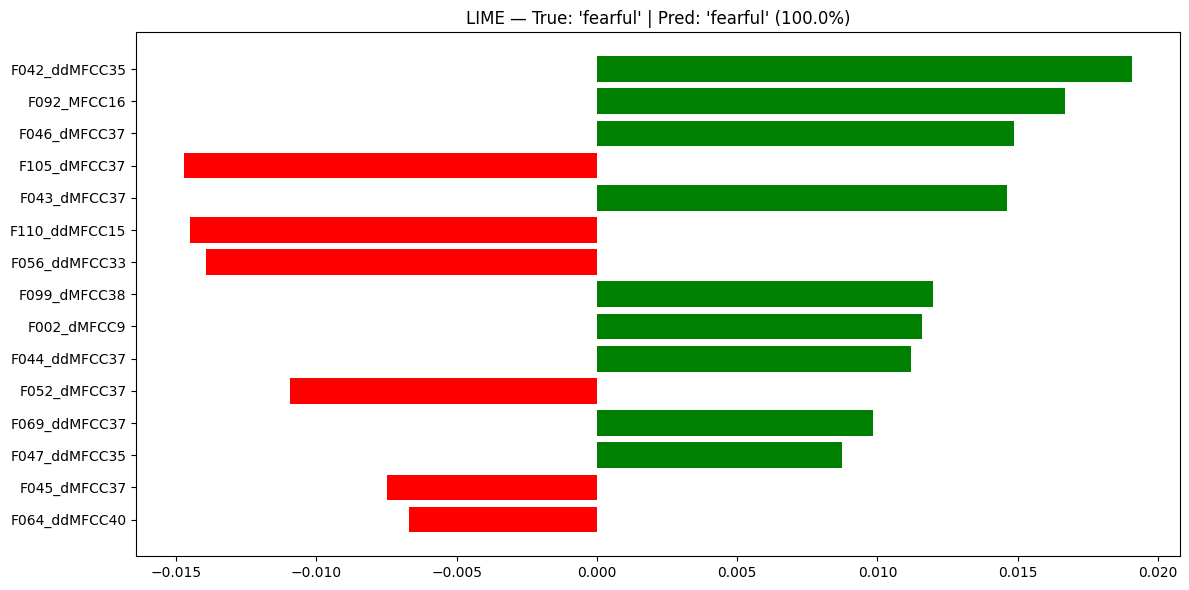


Top 15 LIME features for 'fearful':
Feature                            Weight  Direction
-------------------------------------------------------
  F042_ddMFCC35                  +0.0191  → SUPPORTS
  F092_MFCC16                    +0.0167  → SUPPORTS
  F046_dMFCC37                   +0.0149  → SUPPORTS
  F105_dMFCC37                   -0.0147  → OPPOSES
  F043_dMFCC37                   +0.0146  → SUPPORTS
  F110_ddMFCC15                  -0.0145  → OPPOSES
  F056_ddMFCC33                  -0.0139  → OPPOSES
  F099_dMFCC38                   +0.0120  → SUPPORTS
  F002_dMFCC9                    +0.0116  → SUPPORTS
  F044_ddMFCC37                  +0.0112  → SUPPORTS
  F052_dMFCC37                   -0.0109  → OPPOSES
  F069_ddMFCC37                  +0.0098  → SUPPORTS
  F047_ddMFCC35                  +0.0087  → SUPPORTS
  F045_dMFCC37                   -0.0075  → OPPOSES
  F064_ddMFCC40                  -0.0067  → OPPOSES

Most influential frames (LIME):
  Frame  42 (975ms) → total |wei

In [35]:

def lime_predict(X_flat):
    X_3d = X_flat.reshape(-1, MAX_FRAMES, N_FEATURES)
    return model.predict(X_3d, verbose=0)

# Feature names: Frame_t_MFCC_k, Frame_t_dMFCC_k, Frame_t_ddMFCC_k
feature_names_flat = []
for t in range(MAX_FRAMES):
    for k in range(N_MFCC):
        feature_names_flat.append(f'F{t:03d}_MFCC{k+1}')
    for k in range(N_MFCC):
        feature_names_flat.append(f'F{t:03d}_dMFCC{k+1}')
    for k in range(N_MFCC):
        feature_names_flat.append(f'F{t:03d}_ddMFCC{k+1}')

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_flat,
    feature_names=feature_names_flat,
    class_names=list(le.classes_),
    mode='classification',
    discretize_continuous=False,
    random_state=42
)

# ── Explain one sample ─────────────────────────────────────────
sample_idx  = 0
sample_flat = X_test_flat[sample_idx]
pred_probs  = model.predict(sample_flat.reshape(1, MAX_FRAMES, N_FEATURES), verbose=0)[0]
true_label  = le.inverse_transform([np.argmax(y_test[sample_idx])])[0]
pred_label  = le.inverse_transform([np.argmax(pred_probs)])[0]
confidence  = np.max(pred_probs)

print(f"Sample 0 — True: {true_label}  |  Predicted: {pred_label}  ({confidence:.1%})")
print("\nAll class probabilities:")
for cls, prob in sorted(zip(le.classes_, pred_probs), key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f"  {cls:<12} {prob:.4f}  {bar}")

print("\nRunning LIME (num_samples=3000)...")
lime_exp = lime_explainer.explain_instance(
    data_row=sample_flat,
    predict_fn=lime_predict,
    num_features=15,
    num_samples=3000,
    labels=[np.argmax(pred_probs)]
)

fig = lime_exp.as_pyplot_figure(label=np.argmax(pred_probs))
fig.set_size_inches(12, 6)
plt.title(f"LIME — True: '{true_label}' | Pred: '{pred_label}' ({confidence:.1%})", fontsize=12)
plt.tight_layout()
plt.show()

# Parse frame numbers from feature names to see WHICH FRAMES LIME focuses on
lime_features = lime_exp.as_list(label=np.argmax(pred_probs))[:15]
print(f"\nTop 15 LIME features for '{pred_label}':")
print(f"{'Feature':<30} {'Weight':>10}  Direction")
print("-" * 55)
lime_frame_weights = {}
for feat_str, weight in lime_features:
    direction = "SUPPORTS" if weight > 0 else "OPPOSES"
    print(f"  {feat_str[:28]:<30} {weight:>+.4f}  → {direction}")
    # Extract frame number
    try:
        frame_num = int(feat_str.split('_')[0].replace('F', ''))
        lime_frame_weights[frame_num] = lime_frame_weights.get(frame_num, 0) + abs(weight)
    except:
        pass

if lime_frame_weights:
    top_frames = sorted(lime_frame_weights.items(), key=lambda x: -x[1])[:5]
    print(f"\nMost influential frames (LIME):")
    for frame, weight in top_frames:
        print(f"  Frame {frame:3d} ({frame * HOP_LENGTH / SR * 1000:.0f}ms) → total |weight| = {weight:.4f}")

In [37]:
import pickle
import json
import shutil
import os
import tensorflow as tf

SAVE_DIR = '/kaggle/working/emotion_bilstm_classifier'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving to: {SAVE_DIR}\n")


keras_path = os.path.join(SAVE_DIR, 'emotion_model.keras')
model.save(keras_path)
print(f"✓ Full model saved (.keras)      : {keras_path}")

# .h5 — legacy format, broader compatibility with older tools
h5_path = os.path.join(SAVE_DIR, 'emotion_model.h5')
model.save(h5_path)
print(f"✓ Full model saved (.h5)         : {h5_path}")

# Attention model — same weights, outputs (batch, 130, 1) instead of class probs
# Used exclusively for XAI visualization (Cell 12)
attn_path = os.path.join(SAVE_DIR, 'attention_model.keras')
attention_model.save(attn_path)
print(f"✓ Attention model saved (.keras) : {attn_path}")

# 2. SAVE SCALER


scaler_path = os.path.join(SAVE_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved                   : {scaler_path}")

# 3. SAVE LABEL ENCODER
le_path = os.path.join(SAVE_DIR, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print(f"✓ Label encoder saved            : {le_path}")

# 4. SAVE FEATURE CONFIG


config = {
    "sample_rate":    SR,
    "duration":       DURATION,
    "hop_length":     HOP_LENGTH,
    "n_mfcc":         N_MFCC,
    "max_frames":     MAX_FRAMES,
    "n_features":     N_FEATURES,
    "feature_order":  "mfcc | delta | delta_delta (each 40 dims = 120 total)",
    "delta_width":    9,
    "input_shape":    [MAX_FRAMES, N_FEATURES],
    "num_classes":    int(num_classes),
    "classes":        list(le.classes_),
    "model_type":     "BiLSTM_Attention_FrameLevel",
    "scaler_type":    "StandardScaler_fitted_on_(N*T, F)_reshape",
    "class_weights":  {str(k): v for k, v in class_weight.items()},
    "custom_layers":  ["EmotionModel>SoftmaxOverTime", "EmotionModel>WeightedSum"]
}

config_path = os.path.join(SAVE_DIR, 'feature_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Feature config saved           : {config_path}")

# 5. SAVE INFERENCE SCRIPT


inference_code = '''"""
emotion_inference_bilstm.py
───────────────────────────
Self-contained inference script for the BiLSTM Frame-Level Emotion Classifier.

Requirements:
    pip install tensorflow librosa scikit-learn numpy

Usage:
    from emotion_inference_bilstm import predict_emotion
    result = predict_emotion("audio.wav")
    print(result["predicted_emotion"], result["confidence"])

Files needed (all in same directory as this script):
    emotion_model.keras
    scaler.pkl
    label_encoder.pkl
    feature_config.json
"""

import os
import numpy as np
import librosa
import pickle
import json
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
import keras


# ── Custom layers ─────────────────────────────────────────────────────
# These MUST be defined before load_model is called.
# They are registered with the same package name used during training
# so Keras can match them by name during deserialization.

@keras.utils.register_keras_serializable(package="EmotionModel")
class SoftmaxOverTime(tf.keras.layers.Layer):
    """Softmax over the time axis (axis=1). Replaces Lambda for safe serialization."""
    def call(self, inputs):
        return tf.nn.softmax(inputs, axis=1)
    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="EmotionModel")
class WeightedSum(tf.keras.layers.Layer):
    """Sum over the time axis (axis=1). Produces context vector from weighted states."""
    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=1)
    def get_config(self):
        return super().get_config()


# ── Load all artifacts once at module level (not per call) ────────────
_DIR    = os.path.dirname(os.path.abspath(__file__))

with open(os.path.join(_DIR, "feature_config.json")) as f:
    CONFIG = json.load(f)

with open(os.path.join(_DIR, "scaler.pkl"), "rb") as f:
    SCALER = pickle.load(f)

with open(os.path.join(_DIR, "label_encoder.pkl"), "rb") as f:
    LE = pickle.load(f)

MODEL = tf.keras.models.load_model(
    os.path.join(_DIR, "emotion_model.keras"),
    custom_objects={
        "SoftmaxOverTime": SoftmaxOverTime,
        "WeightedSum":     WeightedSum
    }
)

print(f"Model loaded. Classes: {list(LE.classes_)}")


# ── Feature extraction ────────────────────────────────────────────────
def extract_features(file_path: str) -> np.ndarray:
    """
    Extract (MAX_FRAMES, N_FEATURES) frame-level feature array.
    Must match training extraction exactly:
      - Same SR, duration, hop_length, n_mfcc, delta width
      - Same padding strategy (post-pad with zeros)
      - Same feature order: MFCC | delta | delta-delta
    """
    SR         = CONFIG["sample_rate"]
    DURATION   = CONFIG["duration"]
    HOP        = CONFIG["hop_length"]
    N_MFCC     = CONFIG["n_mfcc"]
    MAX_FRAMES = CONFIG["max_frames"]
    DELTA_W    = CONFIG["delta_width"]

    audio, sr = librosa.load(file_path, sr=SR, duration=DURATION)

    # Pad if shorter than DURATION seconds
    expected = DURATION * SR
    if len(audio) < expected:
        audio = np.pad(audio, (0, expected - len(audio)))

    # MFCC + delta + delta-delta
    mfcc   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, hop_length=HOP)
    delta  = librosa.feature.delta(mfcc, width=DELTA_W)
    delta2 = librosa.feature.delta(mfcc, order=2, width=DELTA_W)

    # Stack → (T, 3*N_MFCC)
    combined = np.vstack([mfcc, delta, delta2]).T

    # Pad or truncate to MAX_FRAMES
    T = combined.shape[0]
    if T < MAX_FRAMES:
        combined = np.pad(combined, ((0, MAX_FRAMES - T), (0, 0)))
    else:
        combined = combined[:MAX_FRAMES]

    return combined.astype(np.float32)   # (MAX_FRAMES, N_FEATURES)


# ── Prediction ────────────────────────────────────────────────────────
def predict_emotion(file_path: str) -> dict:
    """
    Predict emotion from a .wav file.

    Returns
    -------
    dict:
        predicted_emotion : str   — top predicted class name
        confidence        : float — probability of top class (0 to 1)
        all_probabilities : dict  — {emotion: probability} sorted descending
    """
    N_FEAT     = CONFIG["n_features"]
    MAX_FRAMES = CONFIG["max_frames"]

    # 1. Extract frame-level features
    feat = extract_features(file_path)                           # (130, 120)

    # 2. Scale — MUST use the same reshape strategy as training
    #    Training: scaler.fit_transform(X_train.reshape(-1, F))
    #    Inference: scaler.transform(feat.reshape(-1, F))
    feat_scaled = SCALER.transform(feat.reshape(-1, N_FEAT))     # (130, 120)
    feat_scaled = feat_scaled.reshape(1, MAX_FRAMES, N_FEAT)     # (1, 130, 120)

    # 3. Predict
    probs = MODEL.predict(feat_scaled, verbose=0)[0]             # (8,)

    # 4. Decode
    pred_idx   = int(np.argmax(probs))
    pred_label = LE.inverse_transform([pred_idx])[0]
    confidence = float(probs[pred_idx])

    all_probs = {
        emotion: round(float(prob), 4)
        for emotion, prob in zip(LE.classes_, probs)
    }

    return {
        "predicted_emotion": pred_label,
        "confidence":        round(confidence, 4),
        "all_probabilities": dict(
            sorted(all_probs.items(), key=lambda x: -x[1])
        )
    }


# ── CLI usage ─────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    if len(sys.argv) < 2:
        print("Usage: python emotion_inference_bilstm.py path/to/audio.wav")
        sys.exit(1)

    result = predict_emotion(sys.argv[1])
    print(f"\\nPredicted emotion : {result[\\'predicted_emotion\\']}")
    print(f"Confidence        : {result[\\'confidence\\']:.1%}")
    print("\\nAll probabilities:")
    for emotion, prob in result["all_probabilities"].items():
        bar = \\'█\\' * int(prob * 30)
        print(f"  {emotion:<12} {prob:.4f}  {bar}")
'''

script_path = os.path.join(SAVE_DIR, 'emotion_inference_bilstm.py')
with open(script_path, 'w') as f:
    f.write(inference_code)
print(f"✓ Inference script saved         : {script_path}")

# ─────────────────────────────────────────────────────────────────────
# 6. SANITY CHECK — reload and verify predictions match
# ─────────────────────────────────────────────────────────────────────
print("\n── Sanity Check ─────────────────────────────────────────────────")

custom_objects = {
    'SoftmaxOverTime': SoftmaxOverTime,
    'WeightedSum':     WeightedSum
}

loaded_model = tf.keras.models.load_model(
    keras_path,
    custom_objects=custom_objects
)

with open(scaler_path, 'rb') as f:
    loaded_scaler = pickle.load(f)

with open(le_path, 'rb') as f:
    loaded_le = pickle.load(f)

with open(config_path) as f:
    loaded_config = json.load(f)

# Run same sample through both models
sample_check    = X_test_s[0:1]                                  # (1, 130, 120)
prob_original   = model.predict(sample_check, verbose=0)[0]
prob_loaded     = loaded_model.predict(sample_check, verbose=0)[0]

pred_original   = le.inverse_transform([prob_original.argmax()])[0]
pred_loaded     = loaded_le.inverse_transform([prob_loaded.argmax()])[0]
conf_original   = prob_original.max()
conf_loaded     = prob_loaded.max()

print(f"  Original model → {pred_original:<12} (conf: {conf_original:.4f})")
print(f"  Loaded model   → {pred_loaded:<12} (conf: {conf_loaded:.4f})")

if pred_original == pred_loaded:
    print(f"  Predictions match ✓")
else:
    print(f"  ⚠ Predictions differ — something went wrong")

# Verify probability arrays are numerically identical
max_diff = np.abs(prob_original - prob_loaded).max()
print(f"  Max probability diff: {max_diff:.2e}  "
      f"({'✓ negligible' if max_diff < 1e-5 else '⚠ too large'})")

print(f"\n  Classes from loaded LE : {list(loaded_le.classes_)}")
print(f"  n_features from config : {loaded_config['n_features']}")
print(f"  max_frames from config : {loaded_config['max_frames']}")
print(f"  custom_layers recorded : {loaded_config['custom_layers']}")

# ─────────────────────────────────────────────────────────────────────
# 7. ZIP FOR DOWNLOAD
# ─────────────────────────────────────────────────────────────────────
zip_path = '/kaggle/working/emotion_bilstm_deployment'
shutil.make_archive(zip_path, 'zip', SAVE_DIR)
print(f"\n✓ ZIP created: {zip_path}.zip")

# ─────────────────────────────────────────────────────────────────────
# 8. FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("DEPLOYMENT PACKAGE CONTENTS")
print("=" * 62)
total_size = 0
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath  = os.path.join(SAVE_DIR, fname)
    fsize  = os.path.getsize(fpath)
    total_size += fsize
    print(f"  {fname:<42} {fsize/1024:>8.1f} KB")
print(f"  {'─'*52}")
print(f"  {'TOTAL':<42} {total_size/1024/1024:>7.2f} MB")
print(f"\n  ZIP → emotion_bilstm_deployment.zip")
print("=" * 62)
print("""
HOW TO USE AFTER DOWNLOADING:
──────────────────────────────
1. pip install tensorflow librosa scikit-learn numpy

2. Keep all files in the same folder:
     emotion_model.keras
     scaler.pkl
     label_encoder.pkl
     feature_config.json
     emotion_inference_bilstm.py

3. In your project:
     from emotion_inference_bilstm import predict_emotion
     result = predict_emotion("recording.wav")
     print(result["predicted_emotion"])   # e.g. "angry"
     print(result["confidence"])          # e.g. 0.9134

4. Or from terminal:
     python emotion_inference_bilstm.py recording.wav

KEY DIFFERENCES FROM NOTEBOOK 1 DEPLOYMENT:
─────────────────────────────────────────────
  Input shape    : (1, 130, 120)  not (1, 1, 180)
  Custom layers  : must pass custom_objects on load_model
  Scaler reshape : feat.reshape(-1, 120) before transform
  Feature set    : MFCC + delta + delta-delta (no Chroma/Mel)
""")

Saving to: /kaggle/working/emotion_bilstm_classifier

✓ Full model saved (.keras)      : /kaggle/working/emotion_bilstm_classifier/emotion_model.keras
✓ Full model saved (.h5)         : /kaggle/working/emotion_bilstm_classifier/emotion_model.h5
✓ Attention model saved (.keras) : /kaggle/working/emotion_bilstm_classifier/attention_model.keras
✓ Scaler saved                   : /kaggle/working/emotion_bilstm_classifier/scaler.pkl
✓ Label encoder saved            : /kaggle/working/emotion_bilstm_classifier/label_encoder.pkl
✓ Feature config saved           : /kaggle/working/emotion_bilstm_classifier/feature_config.json
✓ Inference script saved         : /kaggle/working/emotion_bilstm_classifier/emotion_inference_bilstm.py

── Sanity Check ─────────────────────────────────────────────────
  Original model → fearful      (conf: 1.0000)
  Loaded model   → fearful      (conf: 1.0000)
  Predictions match ✓
  Max probability diff: 0.00e+00  (✓ negligible)

  Classes from loaded LE : ['angry', '